### Importing Libraries

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Finding Rows 

In [4]:

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

train_data_processed = []
for idx in range(1, 5):
    train_data = pd.read_csv(
        rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\train_FD00{idx}.txt",
        sep=" ", header=None
    )
    train_data.drop(columns=[26, 27], inplace=True)
    train_data.columns = columns

    # Dropping unused columns
    train_data.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'], inplace=True)

    # Computing RUL
    train_data['RUL'] = train_data['time_in_cycles'] / train_data.groupby('unit_number')['time_in_cycles'].transform('max')

    # Dropping identifiers
    train_data.drop(columns=['unit_number', 'setting_1', 'setting_2'], inplace=True)

    train_data_processed.append(train_data)
    print(f"Processed train_FD00{idx}.txt, Rows: {train_data.shape[0]}")

train_data_processed = pd.concat(train_data_processed, ignore_index=True)
pd.DataFrame(train_data_processed)


Processed train_FD001.txt, Rows: 20631
Processed train_FD002.txt, Rows: 53759
Processed train_FD003.txt, Rows: 24720
Processed train_FD004.txt, Rows: 61249


,time_in_cycles,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.005208
1,2,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.010417
2,3,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.015625
3,4,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.020833
4,5,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.026042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160354,251,605.33,1516.36,1315.28,15.46,404.59,2319.66,8840.16,46.08,380.16,2388.73,8185.69,8.4541,372,29.11,17.5234,0.984314
160355,252,643.42,1598.92,1426.77,21.57,567.59,2388.47,9117.12,48.04,535.02,2388.46,8185.47,8.2221,396,39.38,23.7151,0.988235
160356,253,643.68,1607.72,1430.56,21.57,569.04,2388.51,9126.53,48.24,535.41,2388.48,8193.94,8.2525,395,39.78,23.8270,0.992157
160357,254,555.77,1381.29,1148.18,7.96,199.93,2223.78,8403.64,42.53,187.92,2388.83,8125.64,9.0515,337,15.26,9.0774,0.996078


### TRAIN-TEST Splitting

In [5]:

from sklearn.model_selection import train_test_split
X = train_data_processed.drop(columns=['RUL'])
y = train_data_processed['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
pd.DataFrame(X_train)

,time_in_cycles,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
27458,31,555.78,1366.11,1124.18,8.00,195.01,2222.85,8346.60,42.00,183.63,2387.91,8062.77,9.3073,332,14.83,8.8906
101369,84,549.32,1351.79,1118.55,5.71,139.50,2211.94,8319.80,41.76,130.36,2388.03,8086.43,9.3214,330,10.74,6.3737
49186,27,604.94,1501.12,1304.54,15.49,394.52,2318.91,8783.24,45.31,371.88,2388.15,8130.77,8.6683,369,28.49,17.0848
19356,88,642.10,1580.42,1398.26,21.61,554.11,2387.97,9069.27,47.11,521.80,2387.99,8149.45,8.4405,392,38.96,23.3708
129163,98,549.55,1346.82,1132.44,5.72,138.73,2211.73,8316.91,42.20,130.76,2387.84,8069.52,9.3325,331,10.59,6.3985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,173,556.04,1366.44,1134.37,8.00,194.75,2223.03,8356.14,42.12,182.71,2388.11,8069.31,9.3263,335,14.75,8.9002
103694,80,555.25,1359.65,1121.12,7.97,194.07,2222.88,8341.85,41.49,182.53,2388.04,8068.98,9.2705,333,14.84,8.9118
131932,467,607.59,1501.67,1255.12,13.61,341.22,2324.53,8768.11,44.73,321.25,2388.65,8103.51,9.0575,369,24.86,15.0111
146867,61,607.10,1493.34,1256.16,13.65,333.92,2323.98,8715.08,44.39,314.44,2388.08,8057.04,9.2172,366,24.60,14.6742


In [7]:
pd.DataFrame(X_test)

,time_in_cycles,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
40419,160,550.32,1366.76,1137.19,5.72,138.07,2211.60,8317.64,42.77,130.05,2387.69,8076.21,9.4546,335,10.49,6.2175
15356,198,643.48,1599.38,1422.14,21.61,551.43,2388.26,9050.88,48.21,520.15,2388.26,8128.10,8.5011,398,38.59,23.0831
26127,41,555.14,1361.80,1117.57,8.00,195.03,2223.12,8359.20,41.68,183.44,2388.19,8073.46,9.2841,334,14.98,9.0377
43242,2,549.14,1354.84,1122.26,5.72,139.25,2212.22,8337.62,41.82,130.70,2388.32,8099.50,9.2829,330,10.86,6.4181
65092,43,604.44,1501.30,1301.92,15.49,394.91,2318.89,8776.27,45.41,371.99,2388.09,8131.55,8.6281,369,28.74,17.1254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147357,19,536.59,1265.65,1057.38,9.03,175.53,1915.32,8013.25,36.61,164.70,2028.24,7870.26,10.8808,307,14.30,8.5453
126994,21,549.10,1349.09,1121.61,5.71,137.93,2211.56,8302.07,41.84,130.19,2387.67,8070.41,9.3987,330,10.54,6.3767
84009,122,642.35,1582.26,1391.97,21.61,554.32,2388.02,9057.48,47.30,522.40,2388.01,8142.56,8.4122,391,38.80,23.3519
128360,27,604.06,1502.33,1304.32,15.49,394.57,2318.91,8781.24,45.30,371.61,2388.08,8129.90,8.6420,368,28.64,17.2548


In [8]:
pd.DataFrame(y_train)

,RUL
27458,0.158163
101369,0.251497
49186,0.139175
19356,0.310954
129163,0.433628
...,...
119879,0.624549
103694,0.233236
131932,0.955010
146867,0.321053


In [9]:
pd.DataFrame(y_test)

,RUL
40419,0.958084
15356,0.942857
26127,0.271523
43242,0.005291
65092,0.187773
...,...
147357,0.119497
126994,0.160305
84009,0.376543
128360,0.144385


# Training SVM Model

In [10]:
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train LinearSVR
model = LinearSVR(C=1.0, epsilon=0.1, max_iter=50000, random_state=42)
model.fit(X_train_scaled, y_train)




,epsilon,0.1
,tol,0.0001
,C,1.0
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,42
,max_iter,50000


### Saving Model in Pickle

In [11]:
import pickle
with open("svm_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


### Loading the Model and Scaler

In [12]:

with open("svm_model.pkl", "rb") as f:
    Regressor = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)


### Predicting MSE & RMSE

In [13]:
from sklearn.metrics import mean_squared_error
X_test_scaled = scaler.transform(X_test)
y_pred = Regressor.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"\nMean Squared Error: {mse:.6f}")
print(f"Root Mean Squared Error: {rmse:.6f}")


Mean Squared Error: 0.012998
Root Mean Squared Error: 0.114010


# Testing SVM Model

In [14]:

test_data_processed = []
for idx in range(1, 5):
    test_data_rul = pd.read_csv(rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_FD00{idx}.txt", sep=" ", header=None)
    test_data = pd.read_csv(rf"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\test_FD00{idx}.txt", sep=" ", header=None)

    test_data.drop(columns=[26, 27], inplace=True)
    test_data.columns = columns
    test_data.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'], inplace=True)

    eol = []
    for un in test_data['unit_number'].unique():
        temp_data = test_data[test_data['unit_number'] == un]
        eol_temp = test_data_rul.iloc[un - 1].values[0]
        eol_temp_list = [eol_temp] * len(temp_data)
        eol.extend(eol_temp_list)

    test_data['RUL'] = test_data['time_in_cycles'].values / (test_data.groupby('unit_number')['time_in_cycles'].transform('max').values + eol)
    test_data.drop(columns=['unit_number','setting_1','setting_2'], inplace=True)
    test_data_processed.append(test_data)
    print(f"Processed test_FD00{idx}.txt → Rows: {test_data.shape[0]}")

test_data_processed = pd.concat(test_data_processed, ignore_index=True)
pd.DataFrame(test_data_processed)

Processed test_FD001.txt → Rows: 13096
Processed test_FD002.txt → Rows: 33991
Processed test_FD003.txt → Rows: 16596
Processed test_FD004.txt → Rows: 41214


,time_in_cycles,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,0.006993
1,2,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,0.013986
2,3,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,0.020979
3,4,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,0.027972
4,5,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,0.034965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104892,277,550.30,1364.40,1129.17,5.72,138.34,2212.35,8351.73,42.30,130.87,2388.50,8112.61,9.4427,331,10.53,6.2620,0.902280
104893,278,608.00,1494.75,1260.88,13.66,334.75,2324.23,8758.69,44.53,314.51,2388.33,8086.83,9.2772,366,24.33,14.6486,0.905537
104894,279,555.92,1370.65,1130.97,8.00,194.92,2223.57,8370.49,42.33,182.76,2388.64,8100.84,9.3982,336,14.69,8.8389,0.908795
104895,280,608.19,1489.11,1256.25,13.66,333.15,2324.19,8753.04,44.78,314.17,2388.37,8085.24,9.2727,366,24.44,14.6887,0.912052


In [15]:

X_test_final = test_data_processed.drop(columns=['RUL'])
X_test_final_scaled = scaler.transform(X_test_final)
y_test_final = test_data_processed['RUL']

y_pred_final = Regressor.predict(X_test_final_scaled)
mse = mean_squared_error(y_test_final, y_pred_final)
rmse = np.sqrt(mse)
print(f"\n Test Mean Squared Error: {mse:.6f}")
print(f" Test Root Mean Squared Error: {rmse:.6f}")


 Test Mean Squared Error: 0.011157
 Test Root Mean Squared Error: 0.105626


### First 5 Predictions vs True RUL

In [16]:

df_preds = pd.DataFrame({
    "True_RUL": y_test_final.values[:5],
    "Predicted_RUL": y_pred_final[:5]
})

print(df_preds)


   True_RUL  Predicted_RUL
0  0.006993       0.114476
1  0.013986       0.130759
2  0.020979       0.204442
3  0.027972       0.117470
4  0.034965       0.117308


## Plotting for RUL

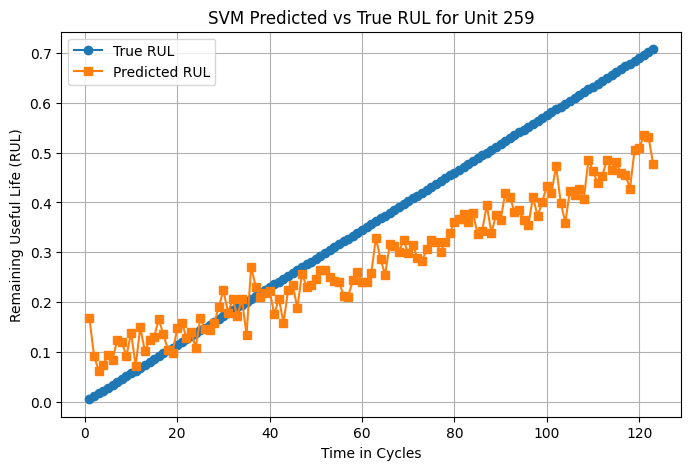


 All plots saved successfully in: C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\SVM_RUL_Plots


In [20]:
from IPython.display import clear_output
import time
import os
fd_001_test_rul = pd.read_csv(r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\RUL_FD002.txt", sep=" ", header=None)
fd_001_test = pd.read_csv(r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\test_FD002.txt", sep=" ", header=None)

fd_001_test.drop(columns=[26, 27], inplace=True)
fd_001_test.columns = columns
fd_001_test.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'], inplace=True)

eol = []
for un in fd_001_test['unit_number'].unique():
    temp_data = fd_001_test[fd_001_test['unit_number'] == un]
    eol_temp = fd_001_test_rul.iloc[un - 1].values[0]
    eol_temp_list = [eol_temp for _ in range(len(temp_data))]
    eol.extend(eol_temp_list)

fd_001_test['RUL'] = fd_001_test['time_in_cycles'].values / (fd_001_test.groupby('unit_number')['time_in_cycles'].transform('max').values + eol)

print(f"\nTotal unique engines: {len(fd_001_test['unit_number'].unique())}")
print(f"Total data rows: {len(fd_001_test)}")

output_dir = r"C:\Users\chenn\OneDrive\Desktop\Machine_Learning_Project\Main\SVM_RUL_Plots"
os.makedirs(output_dir, exist_ok=True)

features = ['time_in_cycles','T24','T30','T50','P15','P30','Nf','Nc','Ps30','phi','NRf','NRc','BPR','htBleed','W31','W32']

for unit_id in fd_001_test['unit_number'].unique():
    unit_data = fd_001_test[fd_001_test['unit_number'] == unit_id]
    true_rul = unit_data['RUL']
    X_test_unit_scaled = scaler.transform(unit_data[features])
    pred_rul = Regressor.predict(X_test_unit_scaled)

    plt.figure(figsize=(8,5))
    plt.plot(unit_data['time_in_cycles'], true_rul, label='True RUL', marker='o')
    plt.plot(unit_data['time_in_cycles'], pred_rul, label='Predicted RUL', marker='s')
    plt.xlabel('Time in Cycles')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.title(f'SVM Predicted vs True RUL for Unit {unit_id}')
    plt.legend()
    plt.grid(True)

    plot_path = os.path.join(output_dir, f"Unit_{unit_id}_SVM_RUL.png")
    plt.savefig(plot_path)
    clear_output(wait=True)
    plt.show()
    time.sleep(0.5)

print("\n All plots saved successfully in:", output_dir)